In [19]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os

EDF_FOLDER = "/content/drive/MyDrive/EEGproj/chb04"

print(os.listdir(EDF_FOLDER))

['chb04-summary.txt', 'chb04_05.edf.seizures', 'chb04_08.edf.seizures', 'chb04_03.edf', 'chb04_02.edf', 'chb04_01.edf', 'chb04_04.edf', 'chb04_05.edf', 'chb04_08.edf']


In [21]:
!pip install mne

In [25]:
import os, re, glob
import numpy as np

try:
    import mne
except ModuleNotFoundError:
    print("MNE n'est pas installé. Installation en cours...")
    os.system("pip install mne")
    import mne

# ---------------- SETTINGS (edit here) ----------------
EDF_FOLDER = "/content/drive/MyDrive/EEGproj"
FILES = ["chb04_03.edf", "chb04_05.edf", "chb04_08.edf"]   # recordings to prepare
SUMMARY_NAME = "chb04-summary.txt"
FS_NEW = 128                                                 # we work at 128 Hz (we keep only 0.5-40 Hz)
CHANNELS = ["FP1-F7", "F7-T7", "T7-P7", "P7-O1", "FP1-F3", "F3-C3", "C3-P3", "P3-O1",
            "FP2-F4", "F4-C4", "C4-P4", "P4-O2", "FP2-F8", "F8-T8", "T8-P8-0", "P8-O2",
            "FZ-CZ", "CZ-PZ"]
OUT_FOLDER = "/content/drive/MyDrive/EEGproj/processed"
# -------------------------------------------------------

os.makedirs(OUT_FOLDER, exist_ok=True)
mne.set_log_level("ERROR")

# Recherche récursive de l'emplacement réel de chaque fichier .edf sur le Drive
def find_file_path(filename, root_dir):
    pattern = os.path.join(root_dir, "**", filename)
    found_paths = glob.glob(pattern, recursive=True)
    if found_paths:
        return found_paths[0]
    return None

# 1) Seizure times (the "answer key") ---------------------------------------
summary_path = find_file_path(SUMMARY_NAME, EDF_FOLDER)
if not summary_path:
    summary_path = os.path.join(EDF_FOLDER, "chb04", SUMMARY_NAME)
    if not os.path.exists(summary_path):
        # Essayer de le télécharger s'il est manquant
        os.makedirs(os.path.dirname(summary_path), exist_ok=True)
        os.system(f"wget -nc -q -P '{os.path.dirname(summary_path)}' https://physionet.org/files/chbmit/1.0.0/chb04/{SUMMARY_NAME}")

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"{SUMMARY_NAME} introuvable dans {EDF_FOLDER}. Veuillez le télécharger.")

def parse_summary(path):
    """Returns {edf_name: [(start_s, end_s), ...]}"""
    text = open(path, errors="ignore").read()
    out = {}
    for block in re.split(r"File Name:\s*", text)[1:]:
        name = block.split()[0]
        starts = re.findall(r"Seizure\s*\d*\s*Start Time:\s*(\d+)", block)
        ends = re.findall(r"Seizure\s*\d*\s*End Time:\s*(\d+)", block)
        out[name] = [(int(a), int(b)) for a, b in zip(starts, ends)]
    return out

SUMMARY = parse_summary(summary_path)

# 2) Clean one recording ----------------------------------------------------
def preprocess_file(fname):
    cache = os.path.join(OUT_FOLDER, fname.replace(".edf", ".npz"))
    if fname not in SUMMARY:
        raise KeyError(f"{fname} is not listed in {SUMMARY_NAME}")
    seizures = np.array(SUMMARY[fname], dtype=int).reshape(-1, 2)
    if os.path.exists(cache):                               # already done earlier -> reload
        d = np.load(cache)
        return dict(signal=d["signal"], seizures=d["seizures"])

    file_path = find_file_path(fname, EDF_FOLDER)
    if not file_path or not os.path.exists(file_path):
        raise FileNotFoundError(f"Le fichier {fname} est introuvable sous {EDF_FOLDER}")

    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    if "T8-P8" in raw.ch_names:
        raw.rename_channels({"T8-P8": "T8-P8-0"})
    missing = [c for c in CHANNELS if c not in raw.ch_names]
    if missing:
        raise ValueError(f"{fname}: missing channels {missing}")
    raw.pick(CHANNELS)
    raw.filter(0.5, 40.0, verbose=False)
    raw.resample(FS_NEW, verbose=False)
    sig = raw.get_data().astype(np.float32) * 1e6

    med = np.median(sig, axis=1, keepdims=True)
    q75, q25 = np.percentile(sig, [75, 25], axis=1)
    sig = (sig - med) / ((q75 - q25)[:, None] + 1e-6)
    sig = np.clip(sig, -20, 20)

    np.savez_compressed(cache, signal=sig, seizures=seizures)
    return dict(signal=sig, seizures=seizures)

# 3) Loop over all files ----------------------------------------------------
DATA = {}
for f in FILES:
    try:
        DATA[f] = preprocess_file(f)
    except Exception as e:
        print(f"SKIPPED {f}: {e}")

print(f"\n{'file':14s} {'minutes':>8s}  {'shape':>16s}  seizures (start-end, seconds)")
for f, d in DATA.items():
    print(f"{f:14s} {d['signal'].shape[1] / FS_NEW / 60:8.1f}  {str(d['signal'].shape):>16s}  "
          f"{[(int(a), int(b)) for a, b in d['seizures']]}")
print("\nSaved in:", OUT_FOLDER)


file            minutes             shape  seizures (start-end, seconds)
chb04_03.edf      240.0     (18, 1843200)  []
chb04_05.edf      158.9     (18, 1220608)  [(7804, 7853)]
chb04_08.edf      240.0     (18, 1843200)  [(6446, 6557)]

Saved in: /content/drive/MyDrive/EEGproj/processed


In [23]:
# ===================== CELL 3 : EEGNet TRAINING + TEST =====================
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score

# ---------------- SETTINGS (edit here) ----------------
TEST_FILE = "chb04_08.edf"       # used ONLY at the very end. The model never sees it during training.
EPOCHS = 40                      # fixed number of rounds (no early stopping: we have no separate validation data)
BATCH = 64
LR = 1e-3
NORMAL_PER_SEIZURE = 3           # each round: all seizure windows + 3x as many random normal windows
SHUFFLE_LABELS = False           # set True once: if the score is still good, something leaks
SEED = 42
# -------------------------------------------------------

WIN_S, MIN_OVERLAP_S, EVAL_STEP_S, SMOOTH = 10, 5, 5, 3
WIN = WIN_S * FS_NEW
N_CH = len(CHANNELS)
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "(use a GPU runtime for speed)" if device == "cpu" else "")

TRAIN_FILES = [f for f in DATA if f != TEST_FILE]
assert TEST_FILE in DATA, f"{TEST_FILE} was not preprocessed"
assert len(TRAIN_FILES) > 0

def overlaps(starts, seizures):
    """seconds of each window [t, t+10] that lie inside a seizure"""
    ov = np.zeros(len(starts))
    for a, b in seizures:
        ov += np.clip(np.minimum(starts + WIN_S, b) - np.maximum(starts, a), 0, None)
    return ov

# ---- 1) Which windows can the model learn from? (1-second grid) ----
pos, neg = [], []
for f in TRAIN_FILES:
    dur = DATA[f]["signal"].shape[1] / FS_NEW
    t = np.arange(0, int(dur) - WIN_S + 1)
    ov = overlaps(t, DATA[f]["seizures"])
    pos += [(f, int(x)) for x in t[ov >= MIN_OVERLAP_S]]      # seizure windows
    neg += [(f, int(x)) for x in t[ov == 0]]                  # clearly normal windows (ambiguous ones are skipped)
print(f"Train files: {TRAIN_FILES} | seizure windows: {len(pos)} | normal windows: {len(neg)}")
print(f"Test file  : {TEST_FILE} | seizures: {[(int(a), int(b)) for a, b in DATA[TEST_FILE]['seizures']]}")
if len(pos) == 0:
    raise RuntimeError("No seizure in the training files: nothing to learn. Choose another TEST_FILE or add files.")
if len(DATA[TEST_FILE]["seizures"]) == 0:
    print("WARNING: the test file has no seizure, so sensitivity cannot be measured. Choose another TEST_FILE.")

def make_windows(items, augment):
    xs = []
    for f, t in items:
        sig = DATA[f]["signal"]
        s = int(t * FS_NEW)
        if augment:
            s += int(rng.integers(-FS_NEW // 2, FS_NEW // 2 + 1))   # shift by up to 0.5 s
        s = int(np.clip(s, 0, sig.shape[1] - WIN))
        x = sig[:, s:s + WIN].copy()
        if augment:
            x *= rng.uniform(0.85, 1.15)                              # amplitude change
            x += rng.normal(0, 0.05, x.shape).astype(np.float32)      # a little noise
            if rng.random() < 0.3:
                x[int(rng.integers(0, N_CH))] = 0                     # one channel "unplugged"
        xs.append(x)
    return torch.tensor(np.stack(xs)[:, None, :, :], dtype=torch.float32)

# ---- 2) EEGNet (compact CNN made for EEG) ----
class EEGNet(nn.Module):
    def __init__(self, n_ch, n_times, F1=8, D=2, F2=16, kern=63, drop=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern), padding="same", bias=False),        # learns frequency filters
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_ch, 1), groups=F1, bias=False),        # learns spatial patterns (electrodes)
            nn.BatchNorm2d(F1 * D), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(drop))
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 15), padding="same", groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, 1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(drop))
        with torch.no_grad():
            n_feat = self.block2(self.block1(torch.zeros(1, 1, n_ch, n_times))).numel()
        self.head = nn.Linear(n_feat, 2)

    def forward(self, x):
        return self.head(self.block2(self.block1(x)).flatten(1))

model = EEGNet(N_CH, WIN).to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()))
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
lossf = nn.CrossEntropyLoss()

# ---- 3) Training: every round uses a NEW random sample of normal windows ----
t0 = time.time()
for ep in range(1, EPOCHS + 1):
    n_neg = min(len(neg), NORMAL_PER_SEIZURE * len(pos))
    items = pos + [neg[i] for i in rng.choice(len(neg), n_neg, replace=False)]
    labels = np.array([1] * len(pos) + [0] * n_neg)
    if SHUFFLE_LABELS:
        rng.shuffle(labels)
    order = rng.permutation(len(items))
    model.train(); total = 0.0
    for i in range(0, len(order), BATCH):
        idx = order[i:i + BATCH]
        if len(idx) < 2:
            continue
        xb = make_windows([items[j] for j in idx], augment=True).to(device)
        yb = torch.tensor(labels[idx]).to(device)
        opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
        total += loss.item() * len(idx)
    sched.step()
    if ep == 1 or ep % 5 == 0 or ep == EPOCHS:
        print(f"round {ep:3d}/{EPOCHS} | training loss {total / len(items):.4f} | {time.time() - t0:.0f}s")

def predict(items):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(items), 128):
            xb = make_windows(items[i:i + 128], augment=False).to(device)
            out.append(torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy())
    return np.concatenate(out)

# quick check: did it learn the TRAINING data? (this is NOT a performance result)
sp = predict(pos[:300]); sn = predict([neg[i] for i in rng.choice(len(neg), min(600, len(neg)), replace=False)])
print(f"\nOn training data: seizure windows detected {np.mean(sp >= 0.5):.0%}, normal windows wrongly flagged {np.mean(sn >= 0.5):.0%}")

# ---- 4) Final test on the held-out recording (complete, every window, every quiet hour) ----
sig_len = DATA[TEST_FILE]["signal"].shape[1] / FS_NEW
starts = np.arange(0, int(sig_len) - WIN_S + 1, EVAL_STEP_S)
y_true = (overlaps(starts, DATA[TEST_FILE]["seizures"]) >= MIN_OVERLAP_S).astype(int)
scores = predict([(TEST_FILE, int(s)) for s in starts])
smooth = np.convolve(scores, np.ones(SMOOTH) / SMOOTH, mode="same")

def events(score, thr):
    on, ev, i = score >= thr, [], 0
    while i < len(on):
        if on[i]:
            j = i
            while j + 1 < len(on) and on[j + 1]:
                j += 1
            ev.append((starts[i], starts[j] + WIN_S)); i = j + 1
        else:
            i += 1
    return ev

hours = sig_len / 3600
print(f"\nTEST on {TEST_FILE} ({hours:.2f} h, {len(DATA[TEST_FILE]['seizures'])} seizure(s))")
if y_true.sum() and y_true.sum() < len(y_true):
    print(f"Window-level precision-recall AUC: {average_precision_score(y_true, smooth):.3f} "
          f"(a model guessing at random would get about {y_true.mean():.3f})")
print("threshold | seizures found | false alarms per hour")
for thr in [0.3, 0.5, 0.7, 0.9]:
    ev = events(smooth, thr); sz = DATA[TEST_FILE]["seizures"]
    found = sum(any(e0 < b and e1 > a for e0, e1 in ev) for a, b in sz)
    false_alarms = sum(not any(e0 < b and e1 > a for a, b in sz) for e0, e1 in ev)
    print(f"   {thr:.1f}    |    {found}/{len(sz)}        | {false_alarms / hours:.1f}")

# ---- 5) Save everything for the interface ----
table = pd.DataFrame({"recording_id": TEST_FILE, "start_time": starts,
                      "end_time": starts + WIN_S, "probability": smooth})
table.to_csv(os.path.join(OUT_FOLDER, f"scores_{TEST_FILE.replace('.edf', '')}.csv"), index=False)
torch.save(model.state_dict(), os.path.join(OUT_FOLDER, "eegnet_chb04.pt"))
print("\nSaved: model (eegnet_chb04.pt) and scores table (scores_*.csv) in", OUT_FOLDER)


Device: cuda 
Train files: ['chb04_03.edf', 'chb04_05.edf'] | seizure windows: 50 | normal windows: 23860
Test file  : chb04_08.edf | seizures: [(6446, 6557)]
Parameters: 2650
round   1/40 | training loss 0.6814 | 4s
round   5/40 | training loss 0.4125 | 5s
round  10/40 | training loss 0.2504 | 6s
round  15/40 | training loss 0.2451 | 7s
round  20/40 | training loss 0.2179 | 8s
round  25/40 | training loss 0.1905 | 8s
round  30/40 | training loss 0.1779 | 9s
round  35/40 | training loss 0.1957 | 10s
round  40/40 | training loss 0.1933 | 11s

On training data: seizure windows detected 100%, normal windows wrongly flagged 10%

TEST on chb04_08.edf (4.00 h, 1 seizure(s))
Window-level precision-recall AUC: 0.005 (a model guessing at random would get about 0.008)
threshold | seizures found | false alarms per hour
   0.3    |    0/1        | 0.2
   0.5    |    0/1        | 0.0
   0.7    |    0/1        | 0.0
   0.9    |    0/1        | 0.0

Saved: model (eegnet_chb04.pt) and scores table (sc

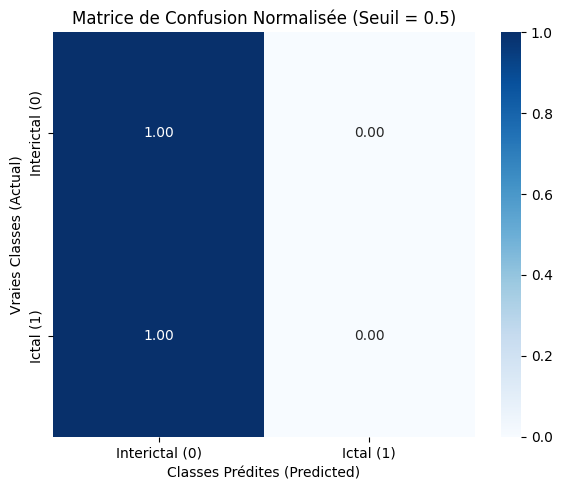

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Définition du seuil de classification pour séparer Interictal (0) de Ictal (1)
threshold = 0.5

# Conversion des probabilités continues (smooth) en prédictions binaires (0 ou 1)
y_pred = (smooth >= threshold).astype(int)

# Calcul de la matrice de confusion en utilisant les variables réelles de l'étape de test
cm = confusion_matrix(y_true, y_pred)

# Normalisation par rapport au nombre d'éléments réels de chaque classe (rappel / sensitivity par classe)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Visualisation graphique de la matrice de confusion normalisée
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Interictal (0)", "Ictal (1)"],
            yticklabels=["Interictal (0)", "Ictal (1)"])

plt.title(f"Matrice de Confusion Normalisée (Seuil = {threshold})")
plt.ylabel("Vraies Classes (Actual)")
plt.xlabel("Classes Prédites (Predicted)")
plt.tight_layout()
plt.show()